## Soham Kharabe
## C-C2-23
## ML Practical 5
## 25/08/2026

Aim : To implement K-Nearest
Neighbor (KNN) algorithm for Classification and Regression.

    · Implement KNN Classifier.


    · Implement KNN Regressor.


    · Compare performance for different values of K.


    · Evaluate the model using appropriate metrics.

    · Visualize decision

    · boundaries (for classification)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score,StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_curve,roc_auc_score)
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
print("Number of Rows:",df.shape[0])

Number of Rows: 768


In [6]:
print("Number of columns:",df.shape[1])

Number of columns: 9


In [7]:
df.shape

(768, 9)

In [8]:
print("Column Names:", df.columns.tolist())

Column Names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [9]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [12]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

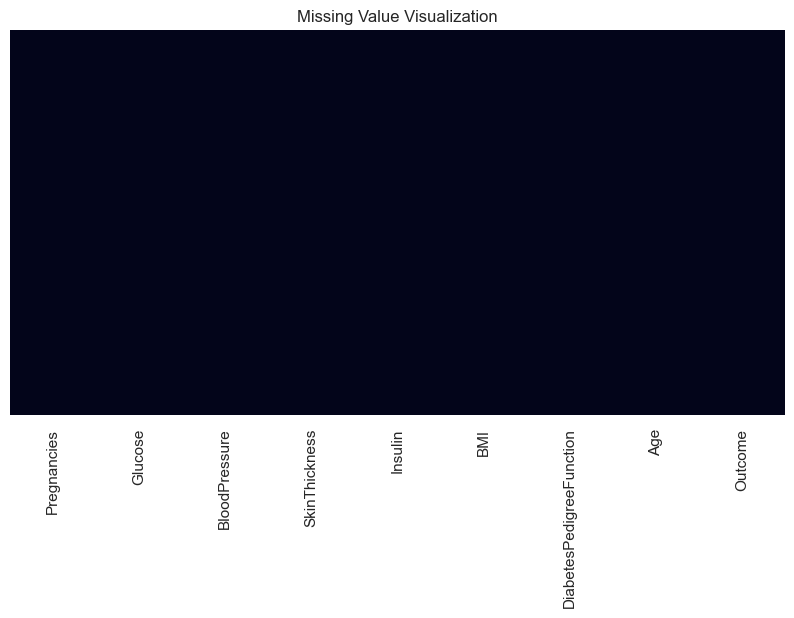

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)
plt.title("Missing Value Visualization")
plt.show()

In [15]:
duplicate_count = df.duplicated().sum()
print("Number of Duplicated Rows:", duplicate_count)

Number of Duplicated Rows: 0


In [18]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


<Axes: xlabel='Outcome', ylabel='count'>

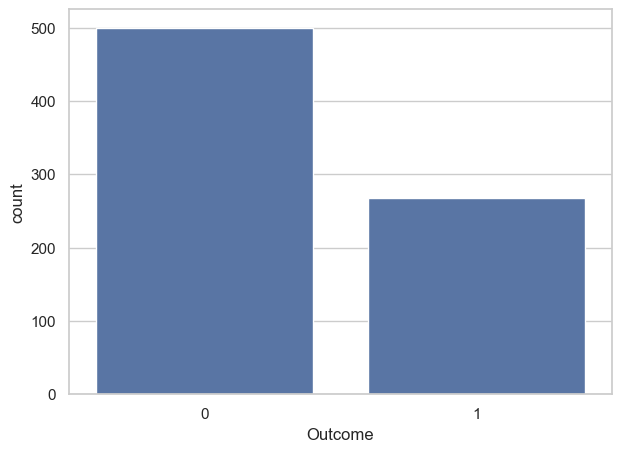

In [21]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x="Outcome"
)

In [20]:
target_percentage = (
    df["Outcome"]
    .value_counts(normalize=True)
    .sort_index()
    *100
)
print(target_percentage)

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


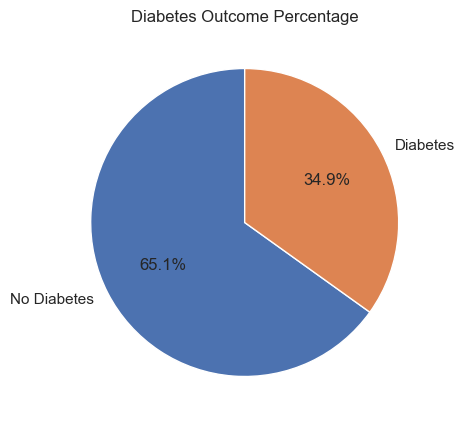

In [22]:
plt.figure(figsize=(7,5))
plt.pie(target_percentage,labels=["No Diabetes","Diabetes"],autopct="%1.1f%%",startangle=90)
plt.title("Diabetes Outcome Percentage")
plt.show()

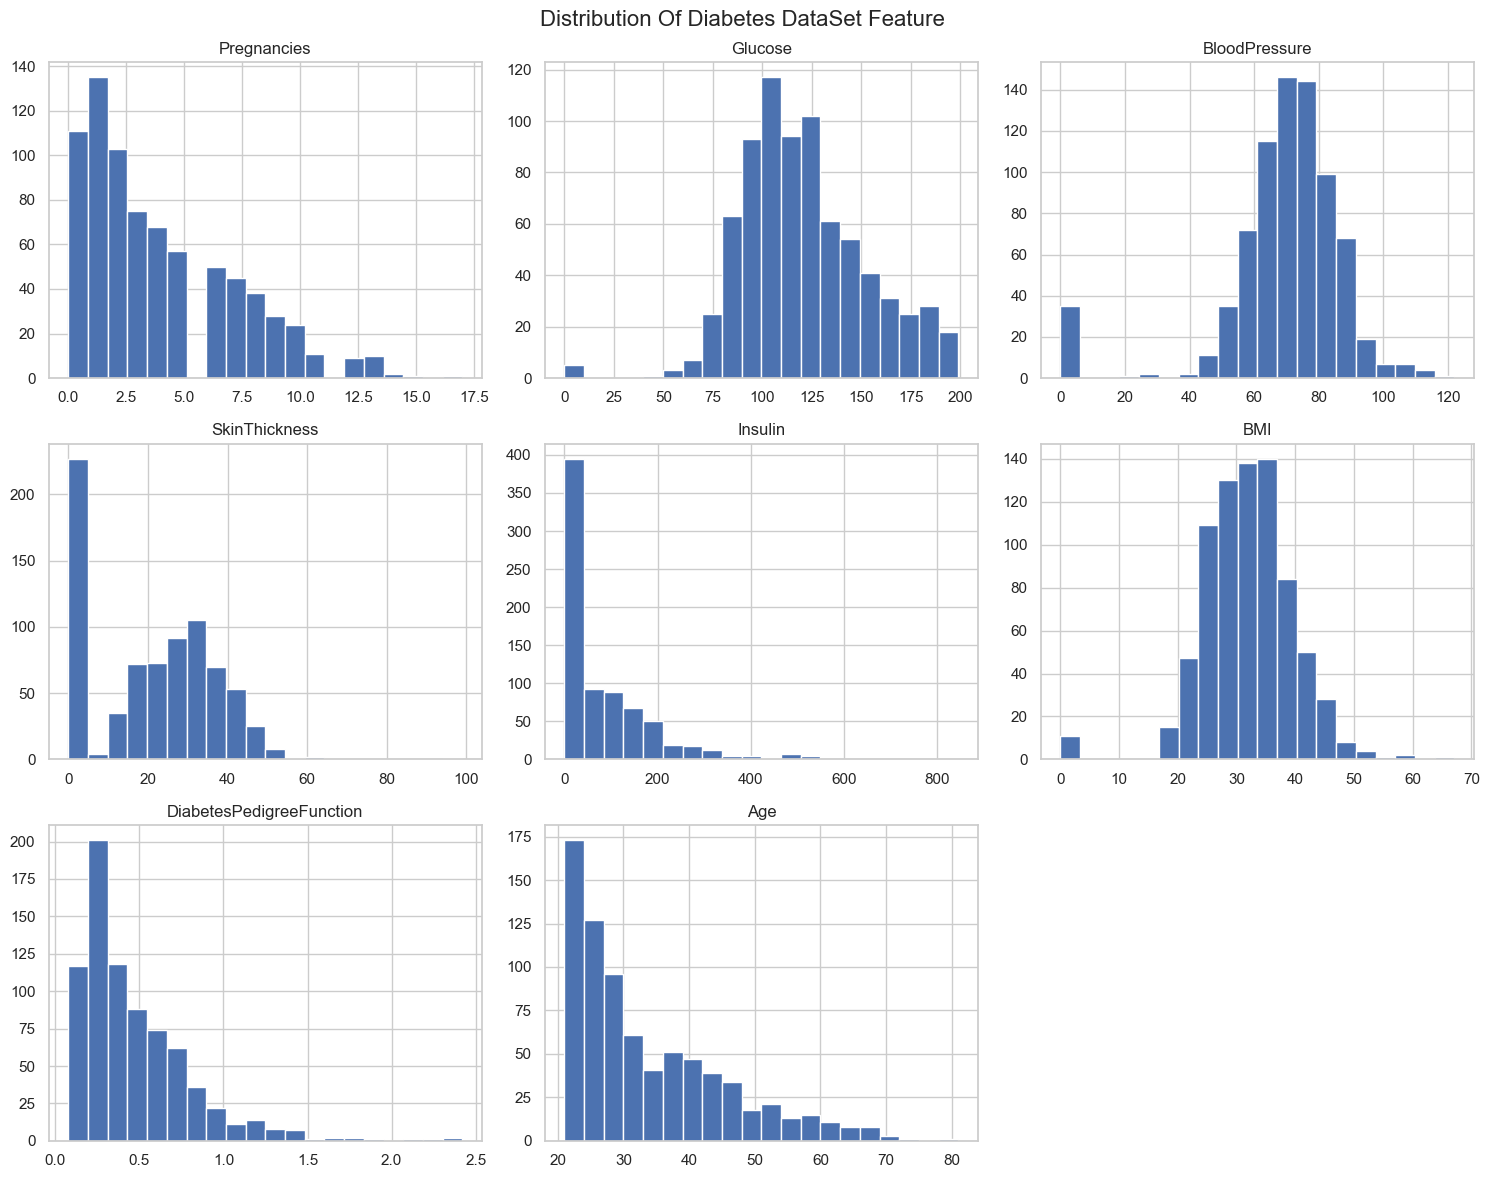

In [28]:
features = df.drop(columns="Outcome").columns
df[features].hist(figsize=(15,12),bins=20)
plt.suptitle("Distribution Of Diabetes DataSet Feature",fontsize=16)
plt.tight_layout()
plt.show()

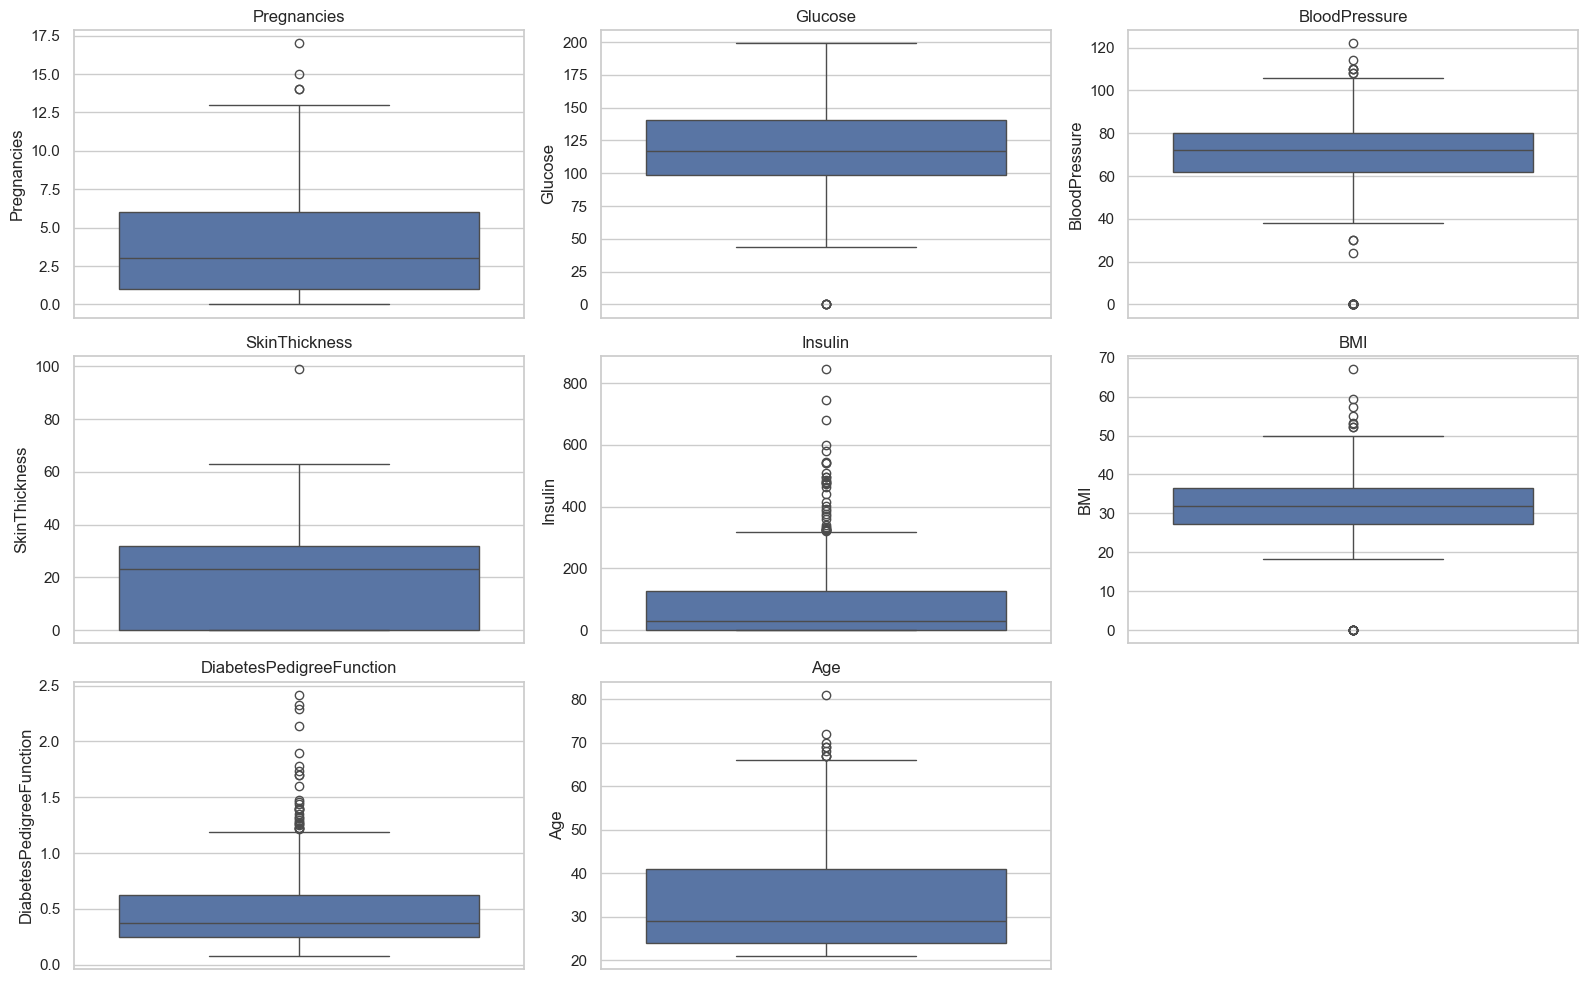

In [30]:
plt.figure(figsize=(16,10))
for i,col in enumerate(features,1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [36]:
zero_columns = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
zero_counts = (df[zero_columns] == 0).sum()
print("Zero Values:")
print(zero_counts)

Zero Values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


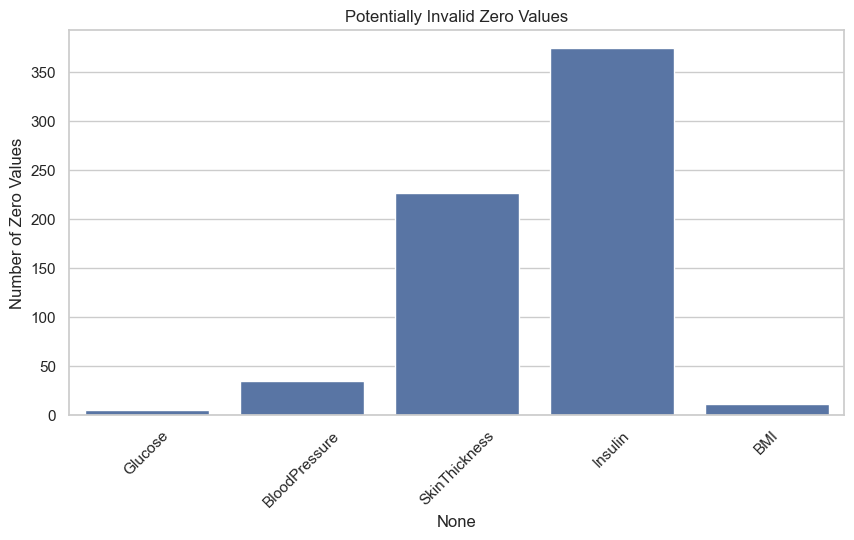

In [37]:
plt.figure(figsize=(10,5))
sns.barplot(x=zero_counts.index,y=zero_counts.values)
plt.xticks(rotation=45)
plt.ylabel("Number of Zero Values")
plt.title("Potentially Invalid Zero Values")
plt.show()

In [40]:
df_clean = df.copy()
df_clean[zero_columns] = df_clean[zero_columns].replace(0,np.nan)
print("Missing Values After Replacing Invalid Zeroes:")
print(df_clean.isnull().sum())

Missing Values After Replacing Invalid Zeroes:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


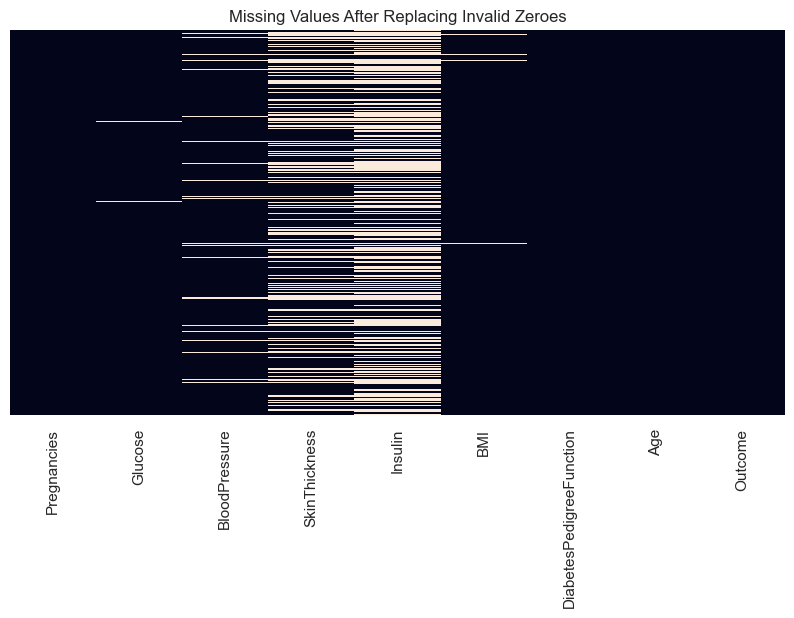

In [41]:
plt.figure(figsize=(10,5))
sns.heatmap(df_clean.isnull(),cbar=False,yticklabels=False)
plt.title("Missing Values After Replacing Invalid Zeroes")
plt.show()

In [45]:
for col in zero_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
print("Missing Values After Median Imputation:")
print(df_clean.isnull().sum())

Missing Values After Median Imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


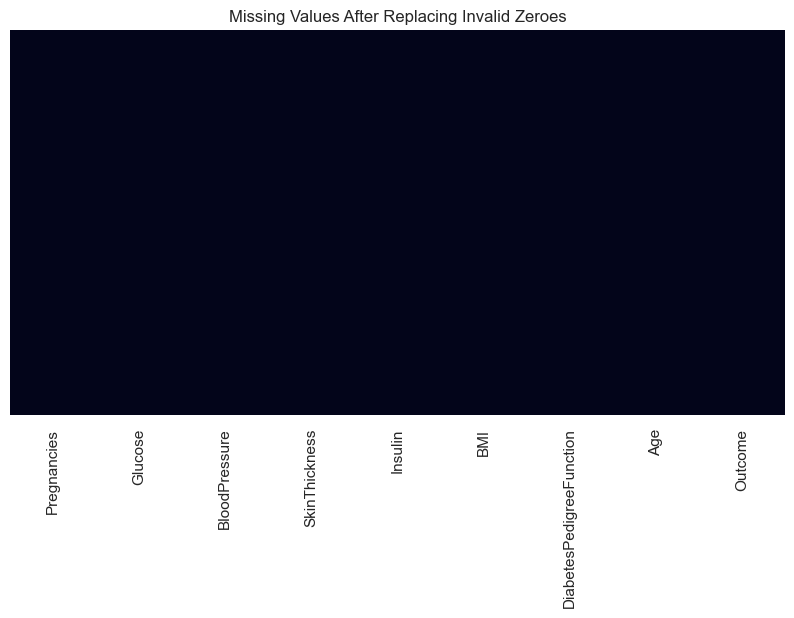

In [46]:
plt.figure(figsize=(10,5))
sns.heatmap(df_clean.isnull(),cbar=False,yticklabels=False)
plt.title("Missing Values After Replacing Invalid Zeroes")
plt.show()

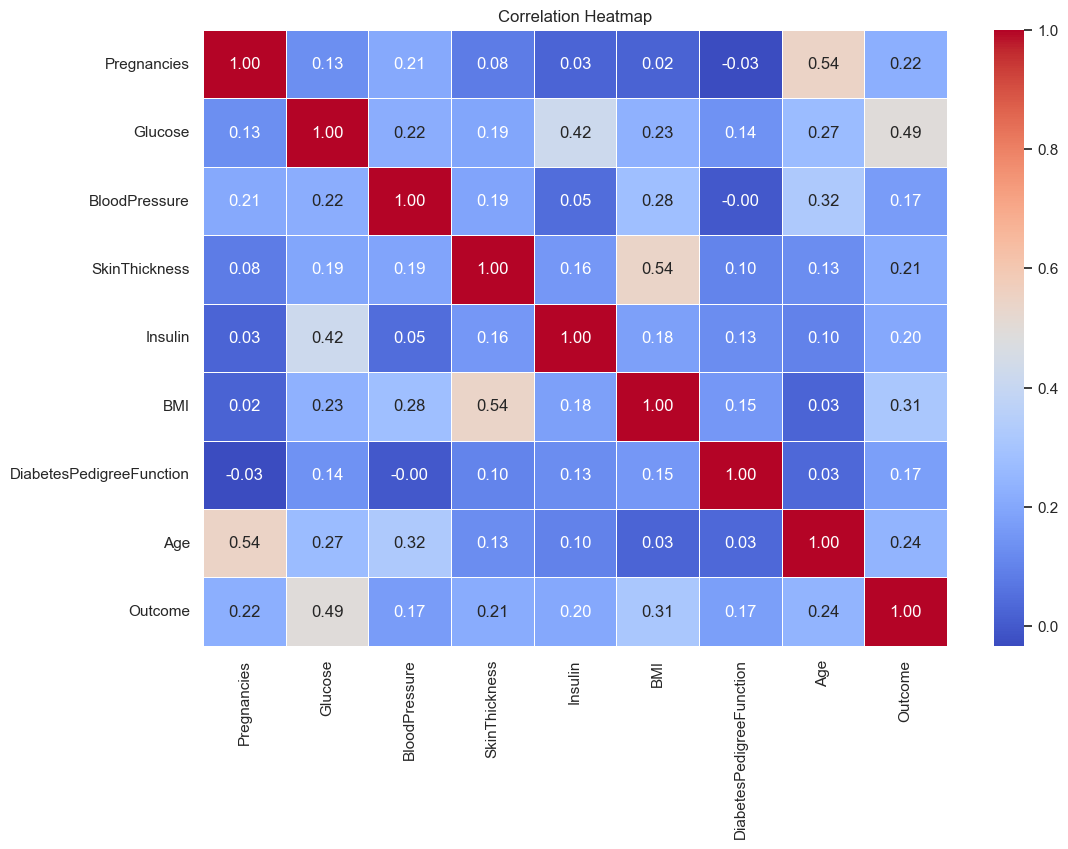

In [47]:
plt.figure(figsize=(12,8))
correlation = df_clean.corr()
sns.heatmap(correlation,annot=True,fmt='.2f',cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()